### **<span style="color:green;">48219193 - Ferdous Ahmed</span>**

# Importing libraries

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import skew
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

# Section 1 - Cleaning

In [6]:
# Loading the Koala dataset
koala_data = pd.read_excel('koalas_dataset.xlsx')

# Displaying the first few rows of the dataset
koala_data.head()

,koala_id,region,habitat,gender,age_in_years,Paw Size,total lengh,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
0,1,1,VIC,m,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0
1,2,1,VIC,f,6.0,16.5,79.5,17.5,16.2,22.5,12.6,3.0,63.5,58.0
2,3,1,VIC,f,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0
3,4,1,VIC,f,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1,VIC,f,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0


In [7]:
# Displaying the first few rows of the dataset
koala_data.tail()

,koala_id,region,habitat,gender,age_in_years,Paw Size,total lengh,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
99,100,7,QLD,m,1.0,16.5,69.5,14.5,11.8,16.0,11.0,1.8,58.0,52.0
100,101,7,q,m,1.0,19.0,70.5,13.6,13.0,14.4,9.7,1.0,60.0,58.0
101,102,7,QLD,f,6.0,18.0,77.0,17.4,10.4,13.5,10.0,0.6,60.0,55.0
102,103,7,QLD,m,4.0,16.5,70.5,16.5,10.9,12.9,10.2,2.4,60.0,54.0
103,104,7,QLD,f,3.0,20.0,77.0,18.6,11.0,17.6,14.9,1.8,63.5,58.5


### Here the column habitat and gender could end up having misspelling in individual cells and other columns are consisted of numeric values so we have to see if there are null cells or outliers in them

In [9]:
koala_data.describe()

,koala_id,region,age_in_years,Paw Size,total lengh,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,102.000000,103.000000,104.000000,104.000000,103.000000
mean,52.500000,3.625000,3.833333,17.009615,75.088462,18.554808,22.650000,18.461765,12.917476,5.886538,62.000000,57.582524
std,30.166206,2.349086,1.909244,1.959518,4.310549,9.761017,87.562416,4.416935,11.160491,39.082636,2.045597,2.775150
min,1.000000,1.000000,1.000000,12.000000,63.000000,7.500000,5.300000,10.300000,5.000000,0.500000,57.000000,50.000000
25%,26.750000,1.000000,2.250000,15.875000,72.000000,15.700000,9.875000,14.550000,9.950000,1.400000,60.500000,56.000000
50%,52.500000,3.000000,3.000000,17.000000,76.000000,17.850000,11.900000,17.950000,11.300000,1.900000,62.000000,57.500000
75%,78.250000,6.000000,5.000000,18.000000,78.000000,19.800000,17.025000,22.500000,13.100000,2.725000,63.000000,59.250000
max,104.000000,7.000000,9.000000,23.000000,84.500000,110.500000,900.800000,27.900000,120.600000,400.500000,67.000000,65.000000


In [10]:
# Counting how many times each Customer ID appears
duplicate_counts = koala_data['koala_id'].value_counts()

# Keeping only the IDs that show up more than once
duplicate_counts = duplicate_counts[duplicate_counts > 1]

# Showing the Customer IDs that are duplicates
print("\nCustomer IDs that are duplicates (appear more than once):")
print(duplicate_counts)


Customer IDs that are duplicates (appear more than once):
Series([], Name: count, dtype: int64)


In [11]:
# Displaying all the unique data
koala_data.nunique()

koala_id               104
region                   7
habitat                  8
gender                   4
age_in_years             9
Paw Size                19
total lengh             34
head_length             71
ear_size                71
foot_length             74
skull_width             64
eye_diameter            33
chest_circumference     19
belly_circumference     24
dtype: int64

In [12]:
# Checking for missing values and data types
missing_values = koala_data.isnull().sum()
data_types = koala_data.dtypes

# Checking for duplicate rows
duplicate_rows = koala_data.duplicated().sum()

# Displaying the results
missing_values, data_types, duplicate_rows

(koala_id               0
 region                 0
 habitat                0
 gender                 0
 age_in_years           2
 Paw Size               0
 total lengh            0
 head_length            0
 ear_size               0
 foot_length            2
 skull_width            1
 eye_diameter           0
 chest_circumference    0
 belly_circumference    1
 dtype: int64,
 koala_id                 int64
 region                   int64
 habitat                 object
 gender                  object
 age_in_years           float64
 Paw Size               float64
 total lengh            float64
 head_length            float64
 ear_size               float64
 foot_length            float64
 skull_width            float64
 eye_diameter           float64
 chest_circumference    float64
 belly_circumference    float64
 dtype: object,
 0)

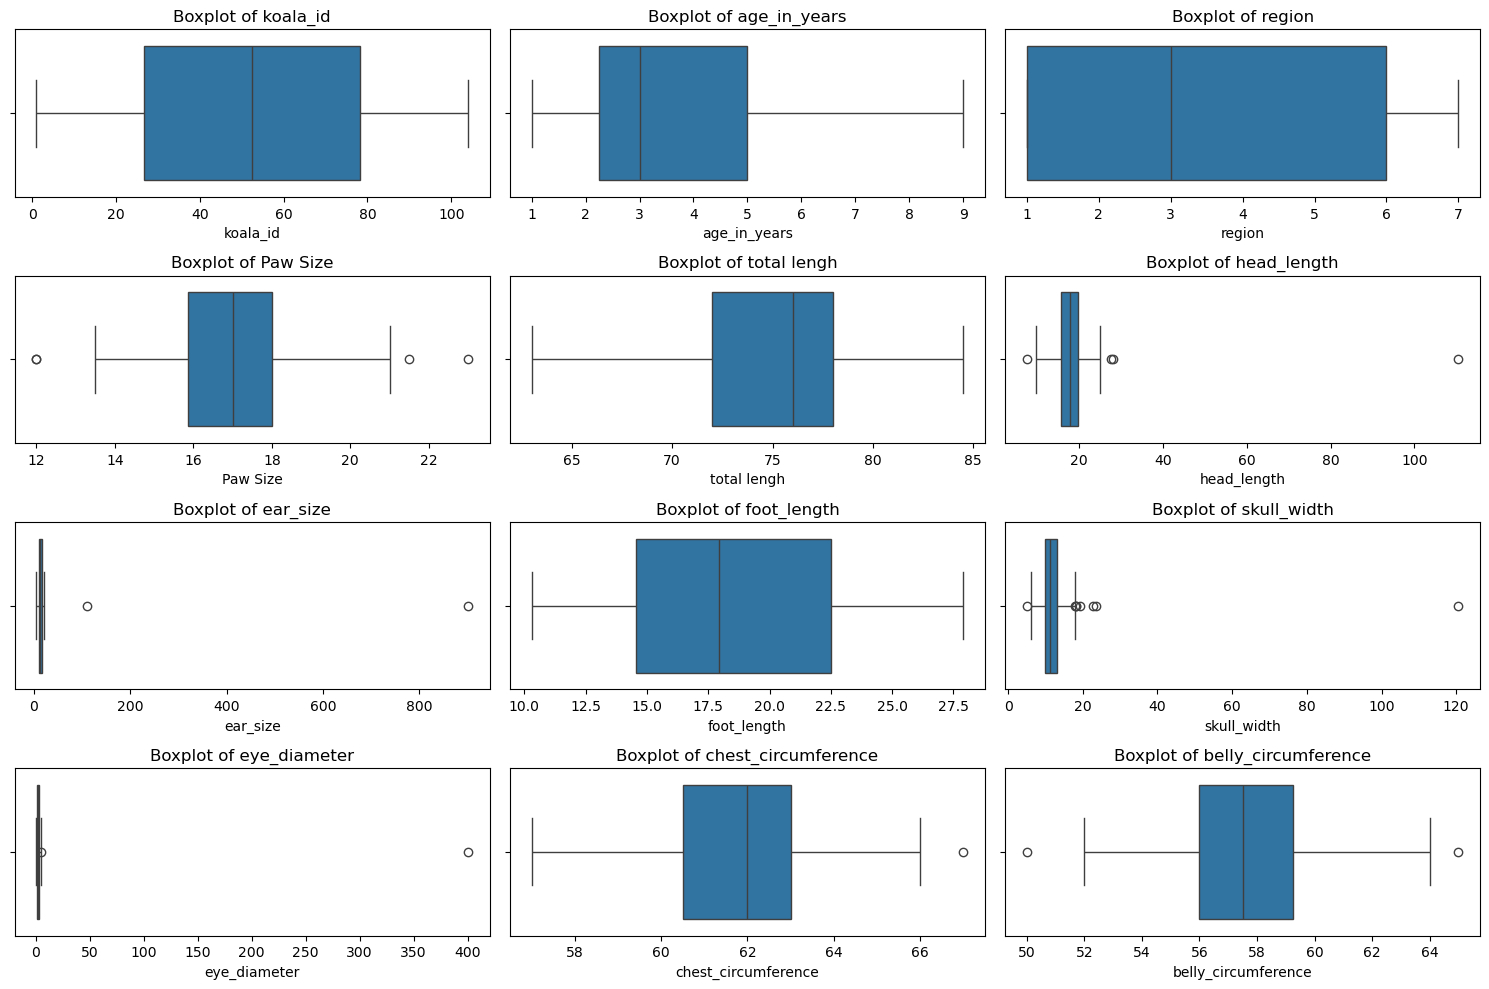

In [13]:
# List of numerical columns
numerical_columns = ['koala_id', 'age_in_years', 'region', 'Paw Size', 'total lengh', 'head_length', 
                     'ear_size', 'foot_length', 'skull_width', 'eye_diameter', 
                     'chest_circumference', 'belly_circumference']

# Create boxplots for all numerical columns to visualize potential outliers
plt.figure(figsize=(15, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=koala_data, x=column)
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

In [14]:
# Filling missing values in the 'age_in_years' column using the mean
mean_age = koala_data['age_in_years'].mean()
koala_data['age_in_years'].fillna(mean_age, inplace=True)


In [15]:
# Filling missing values in the 'foot_length' column using the mean
mean_foot_length = koala_data['foot_length'].mean()
koala_data['foot_length'].fillna(mean_foot_length, inplace=True)

In [16]:
# Filling missing values in the 'skull_width' column using the mean
mean_skull_width = koala_data['skull_width'].mean()
koala_data['skull_width'].fillna(mean_skull_width, inplace=True)

In [17]:
# Filling missing values in the 'belly_circumference' column using the mean
mean_belly_circumference = koala_data['belly_circumference'].mean()
koala_data['belly_circumference'].fillna(mean_belly_circumference, inplace=True)

In [18]:
# Checking if there are still any missing values after filling them
missing_values_after_imputation = koala_data.isnull().sum()

# Showing the result to see if all missing values are handled
missing_values_after_imputation

koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           0
Paw Size               0
total lengh            0
head_length            0
ear_size               0
foot_length            0
skull_width            0
eye_diameter           0
chest_circumference    0
belly_circumference    0
dtype: int64

In [19]:
# Defining a function for removing outliers using the IQR method (Interquartile Range)
def remove_outliers(df, columns):
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df[columns] < (Q1 - 1.5 * IQR)) | (df[columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Removing outliers for numerical columns
numerical_columns = koala_data.select_dtypes(include=['float64', 'int64']).columns
koala_data_cleaned = remove_outliers(koala_data, numerical_columns)

# Checking the shape of the dataset before and after outlier removal
koala_data.shape, koala_data_cleaned.shape, print("The previous and the new shape :")

The previous and the new shape :


((104, 14), (83, 14), None)

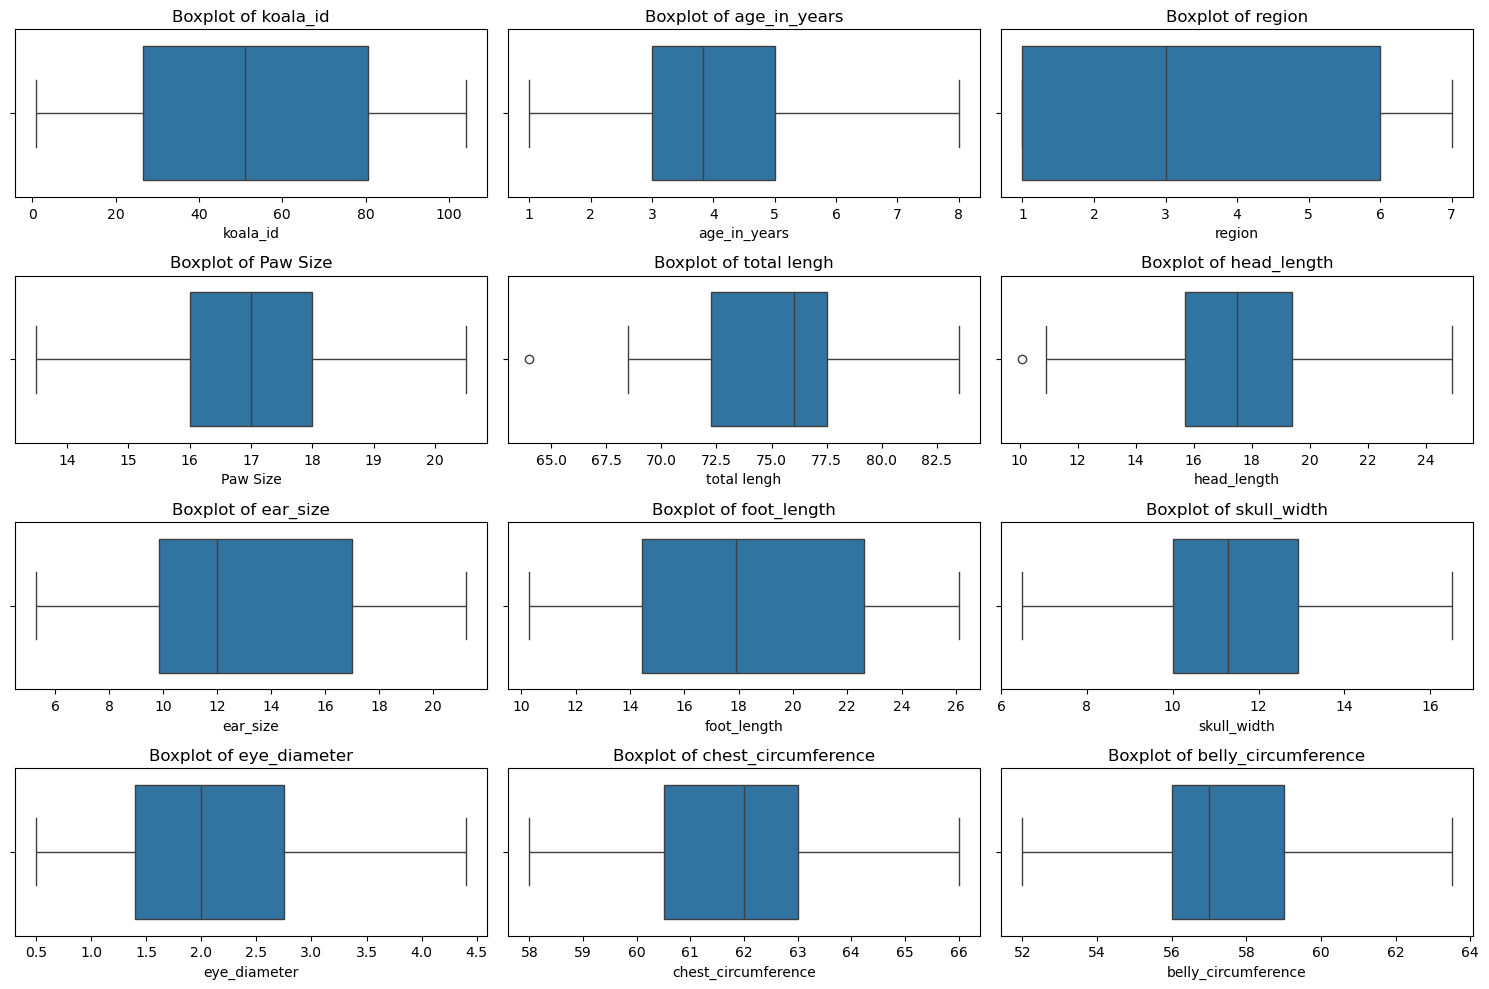

In [20]:
# List of numerical columns
numerical_columns = ['koala_id', 'age_in_years', 'region', 'Paw Size', 'total lengh', 'head_length', 
                     'ear_size', 'foot_length', 'skull_width', 'eye_diameter', 
                     'chest_circumference', 'belly_circumference']

# Create boxplots for all numerical columns to visualize potential outliers
plt.figure(figsize=(15, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=koala_data_cleaned, x=column)
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

In [21]:
# Displaying summary statistics for the cleaned dataset
summary_statistics = koala_data_cleaned.describe()

# Showing the summary statistics
summary_statistics

,koala_id,region,age_in_years,Paw Size,total lengh,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,52.421687,3.602410,3.911647,16.921687,75.080723,17.509639,13.231325,18.259320,11.477319,2.078313,61.819277,57.451807
std,31.031110,2.398881,1.719358,1.554855,3.779517,2.884467,4.237059,4.356051,2.075633,0.929995,1.752313,2.473783
min,1.000000,1.000000,1.000000,13.500000,64.000000,10.100000,5.300000,10.300000,6.500000,0.500000,58.000000,52.000000
25%,26.500000,1.000000,3.000000,16.000000,72.250000,15.700000,9.850000,14.450000,10.000000,1.400000,60.500000,56.000000
50%,51.000000,3.000000,3.833333,17.000000,76.000000,17.500000,12.000000,17.900000,11.300000,2.000000,62.000000,57.000000
75%,80.500000,6.000000,5.000000,18.000000,77.500000,19.400000,17.000000,22.600000,12.908738,2.750000,63.000000,59.000000
max,104.000000,7.000000,8.000000,20.500000,83.500000,24.900000,21.200000,26.100000,16.500000,4.400000,66.000000,63.500000


In [22]:
koala_data['habitat'].unique()

array(['VIC', 'VICtoria', 'Vic', 'QLD', 'Queensland', 'Queenstown', 'qld',
       'q'], dtype=object)

In [23]:
# Standardizing inconsistent habitat values
koala_data_cleaned['habitat'] = koala_data_cleaned['habitat'].replace({
    'VICtoria': 'VIC',
    'Queensland': 'QLD',
    'qld': 'QLD',
    'q': 'QLD',
    'Queenstown': 'QLD'
})

# Checking the cleaned habitat distribution
koala_data_cleaned['habitat'].unique()

array(['VIC', 'QLD'], dtype=object)

In [24]:
koala_data['gender'].unique()

array(['m', 'f', 'female', 'male'], dtype=object)

In [25]:
# Standardize the values in the 'gender' column
koala_data_cleaned['gender'] = koala_data['gender'].replace({
    'female': 'f',  # Replace 'female' with 'f'
    'male': 'm'     # Replace 'male' with 'm'
})

# Verify the changes
koala_data_cleaned['gender'].unique()

array(['m', 'f'], dtype=object)

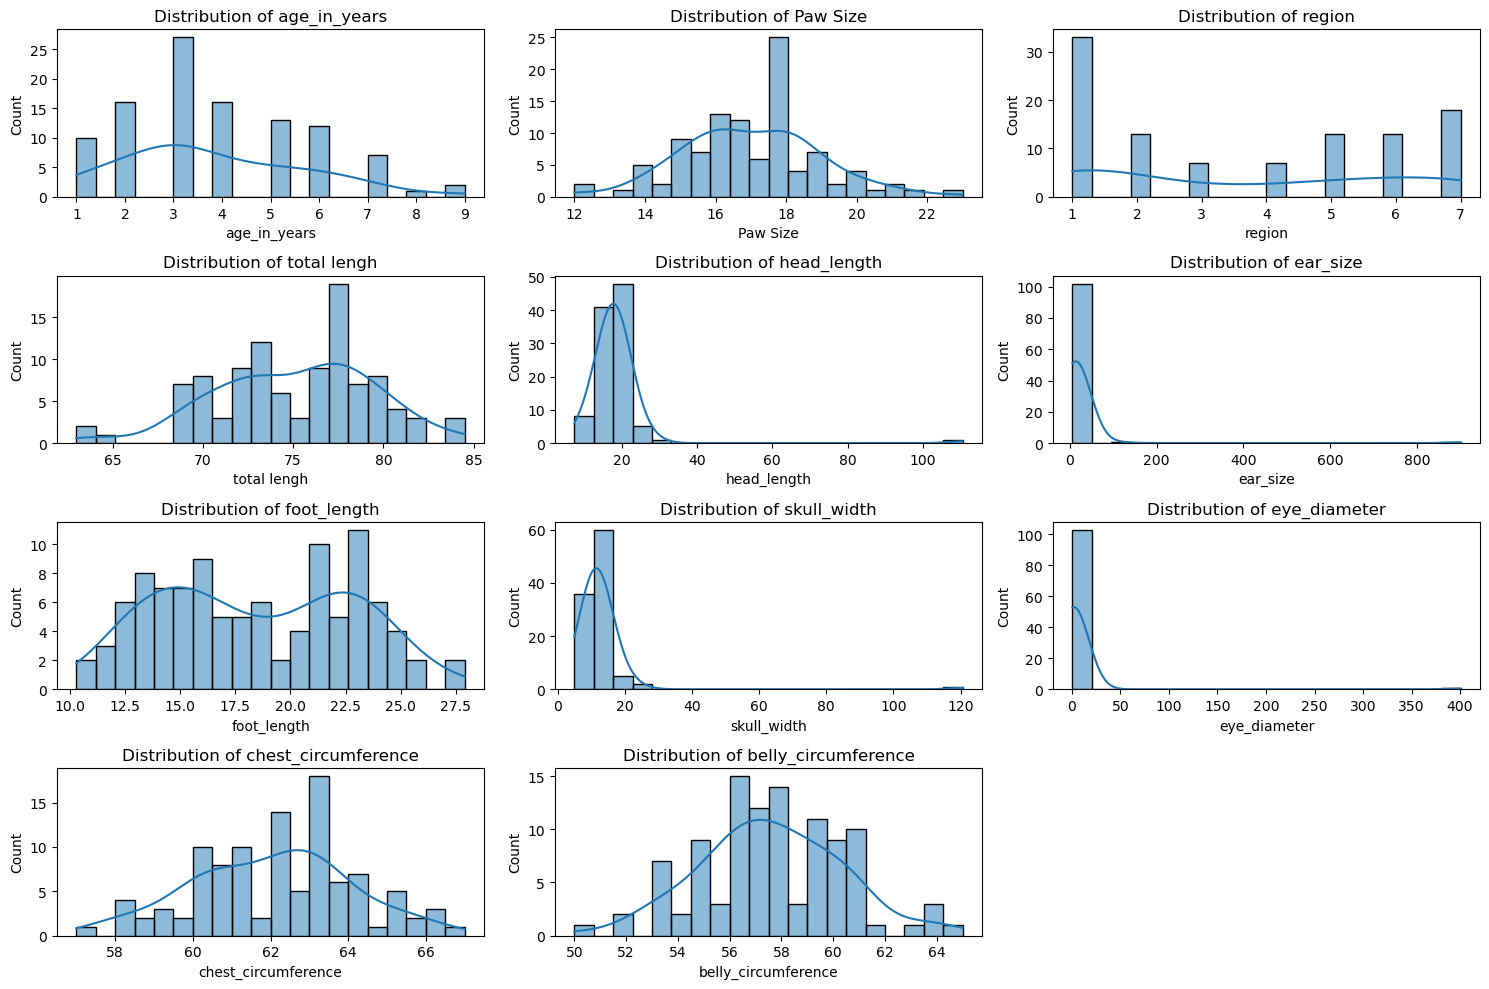

In [26]:
# List of numerical columns
numerical_columns = ['age_in_years', 'Paw Size', 'region', 'total lengh', 'head_length', 
                     'ear_size', 'foot_length', 'skull_width', 'eye_diameter', 
                     'chest_circumference', 'belly_circumference']

# Create histograms for all numerical columns to visualize distributions
plt.figure(figsize=(15, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data=koala_data, x=column, kde=True, bins=20)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

In [27]:
# Calculating skewness for all numerical columns
skewness_values = koala_data[numerical_columns].skew()

# Displaying skewness values for each column
print("Skewness values for each numerical column:")
print(skewness_values)

Skewness values for each numerical column:
age_in_years            0.544263
Paw Size                0.167869
region                  0.187788
total lengh            -0.285266
head_length             8.233721
ear_size                9.992994
foot_length             0.090705
skull_width             9.021706
eye_diameter           10.188536
chest_circumference    -0.055511
belly_circumference     0.078412
dtype: float64


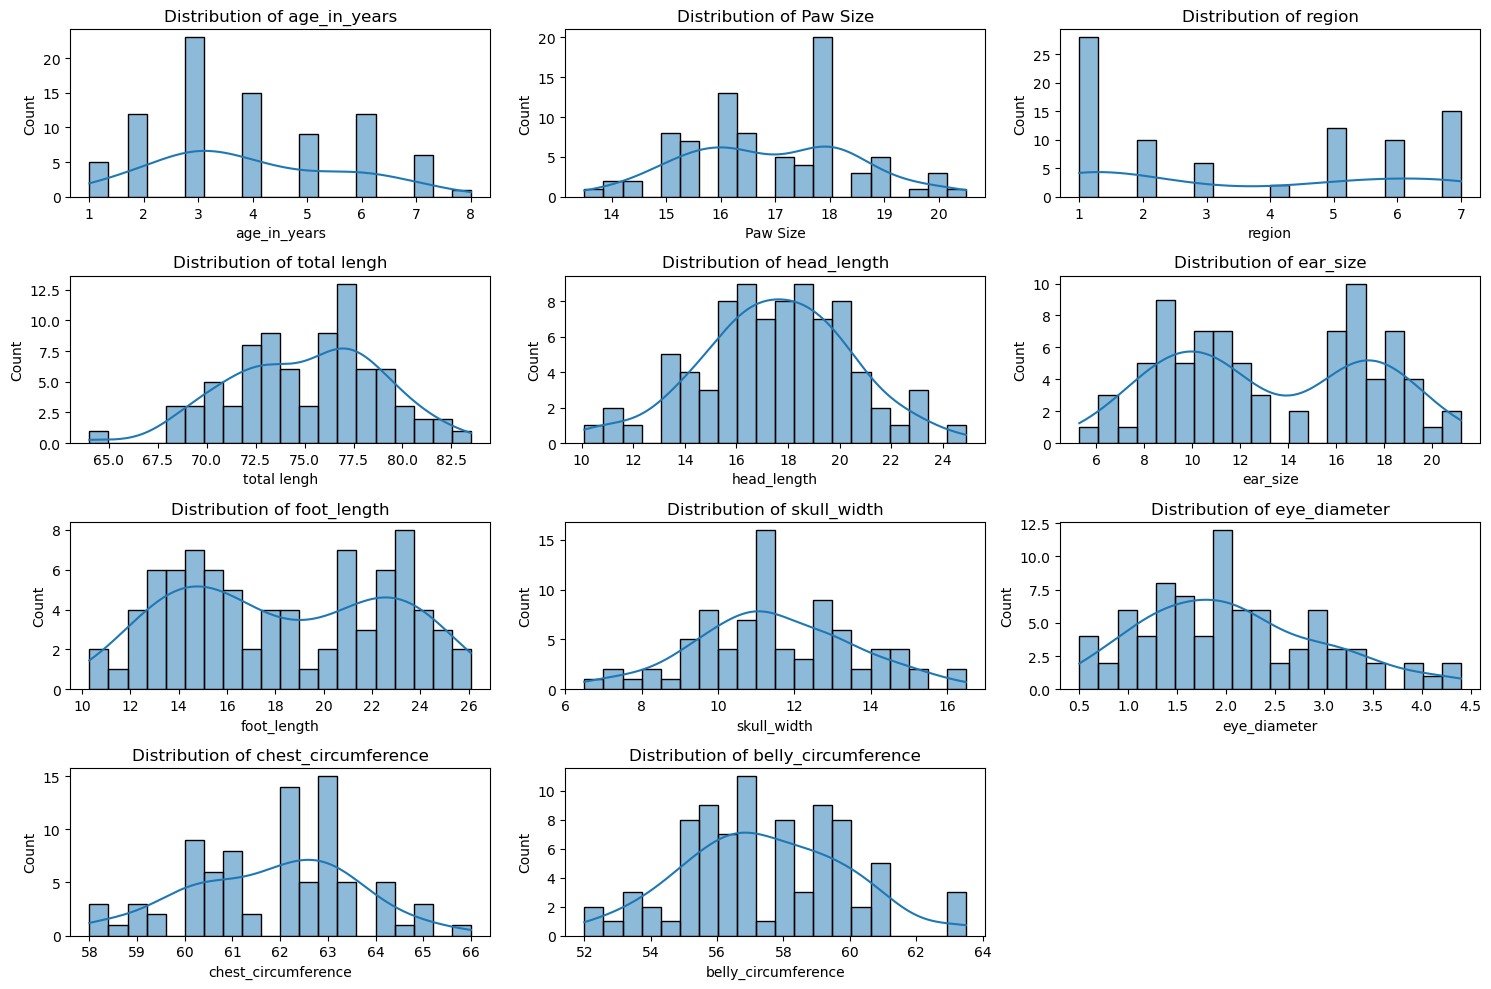

In [28]:
# List of numerical columns
numerical_columns = ['age_in_years', 'Paw Size', 'region', 'total lengh', 'head_length', 
                     'ear_size', 'foot_length', 'skull_width', 'eye_diameter', 
                     'chest_circumference', 'belly_circumference']

# Create histograms for all numerical columns to visualize distributions
plt.figure(figsize=(15, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data=koala_data_cleaned, x=column, kde=True, bins=20)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

In [29]:
# Calculating skewness for all numerical columns
skewness_values = koala_data_cleaned[numerical_columns].skew()

# Displaying skewness values for each column
print("Skewness values for each numerical column:")
print(skewness_values)

Skewness values for each numerical column:
age_in_years           0.347396
Paw Size               0.089723
region                 0.201919
total lengh           -0.233007
head_length           -0.149877
ear_size               0.085520
foot_length            0.062746
skull_width            0.062957
eye_diameter           0.547471
chest_circumference   -0.179984
belly_circumference    0.152553
dtype: float64


In [30]:
# Performing one-hot encoding on the categorical columns
koala_data_encoded = pd.get_dummies(koala_data_cleaned, columns=['habitat', 'gender'], drop_first=False)

# Ensuring that all columns are numerical (converting True/False to 0/1 if necessary)
koala_data_encoded = koala_data_encoded.astype(int)

# Displaying the first few rows of the encoded dataset
koala_data_encoded.head()

,koala_id,region,age_in_years,Paw Size,total lengh,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference,habitat_QLD,habitat_VIC,gender_f,gender_m
0,1,1,8,16,77,19,19,24,15,2,63,61,0,1,0,1
1,2,1,6,16,79,17,16,22,12,3,63,58,0,1,1,0
2,3,1,6,19,83,19,16,25,15,2,65,59,0,1,1,0
3,4,1,6,18,80,18,17,26,12,2,63,59,0,1,1,0
4,5,1,2,16,73,16,18,21,11,2,63,58,0,1,1,0


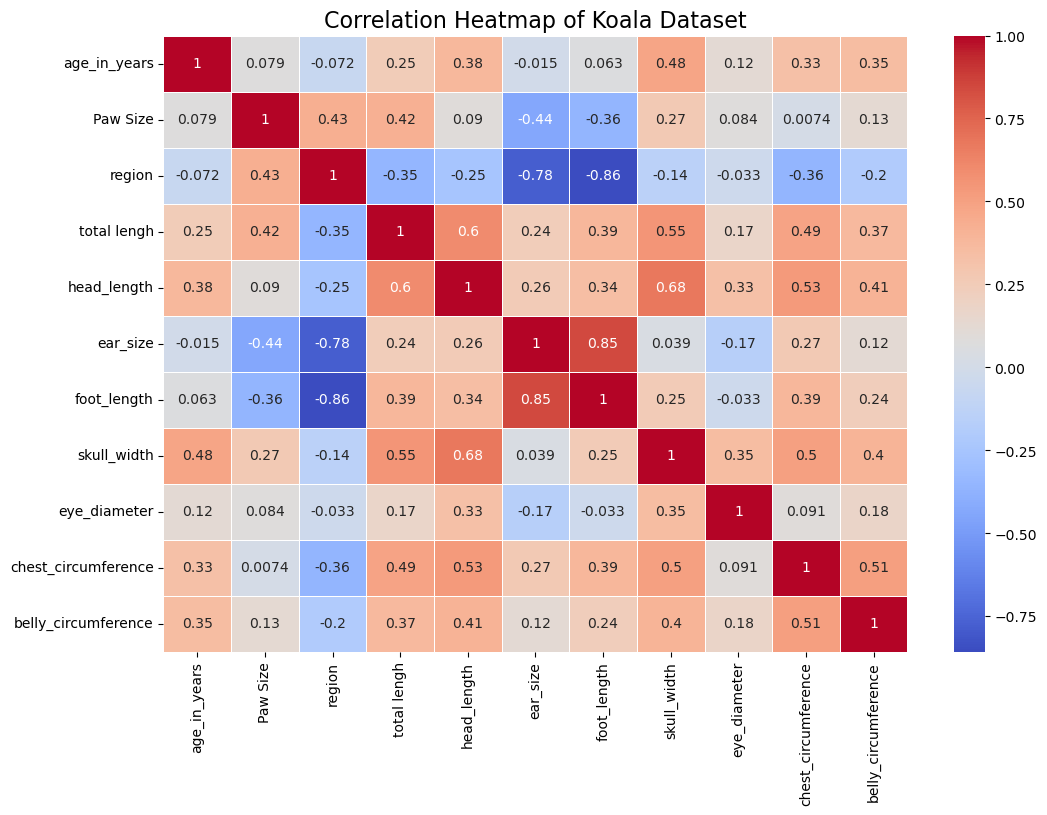

In [83]:
# Calculating the correlation matrix
correlation_matrix = koala_data_encoded[numerical_columns].corr()

# Creating a heatmap to visualize the correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Adding title
plt.title('Correlation Heatmap of Koala Dataset', fontsize=16)

# Display the heatmap
plt.show()

Strong Positive Correlations: The heatmap reveals a strong positive correlation between head length and total length, which indicates that koalas with larger heads tend to have longer bodies. Similarly, paw size is highly correlated with foot length and total length, suggesting that larger koalas tend to have larger paws.

Weak or No Correlation: Some attributes like eye diameter and belly circumference show weaker correlations with other variables. This could indicate that these physical features vary independently of other measurements, providing unique biological diversity in koalas.

This heatmap helps identify the strongest relationships between physical traits, which can be used for further analyses, such as predicting one feature from another.

<Figure size 1200x800 with 0 Axes>

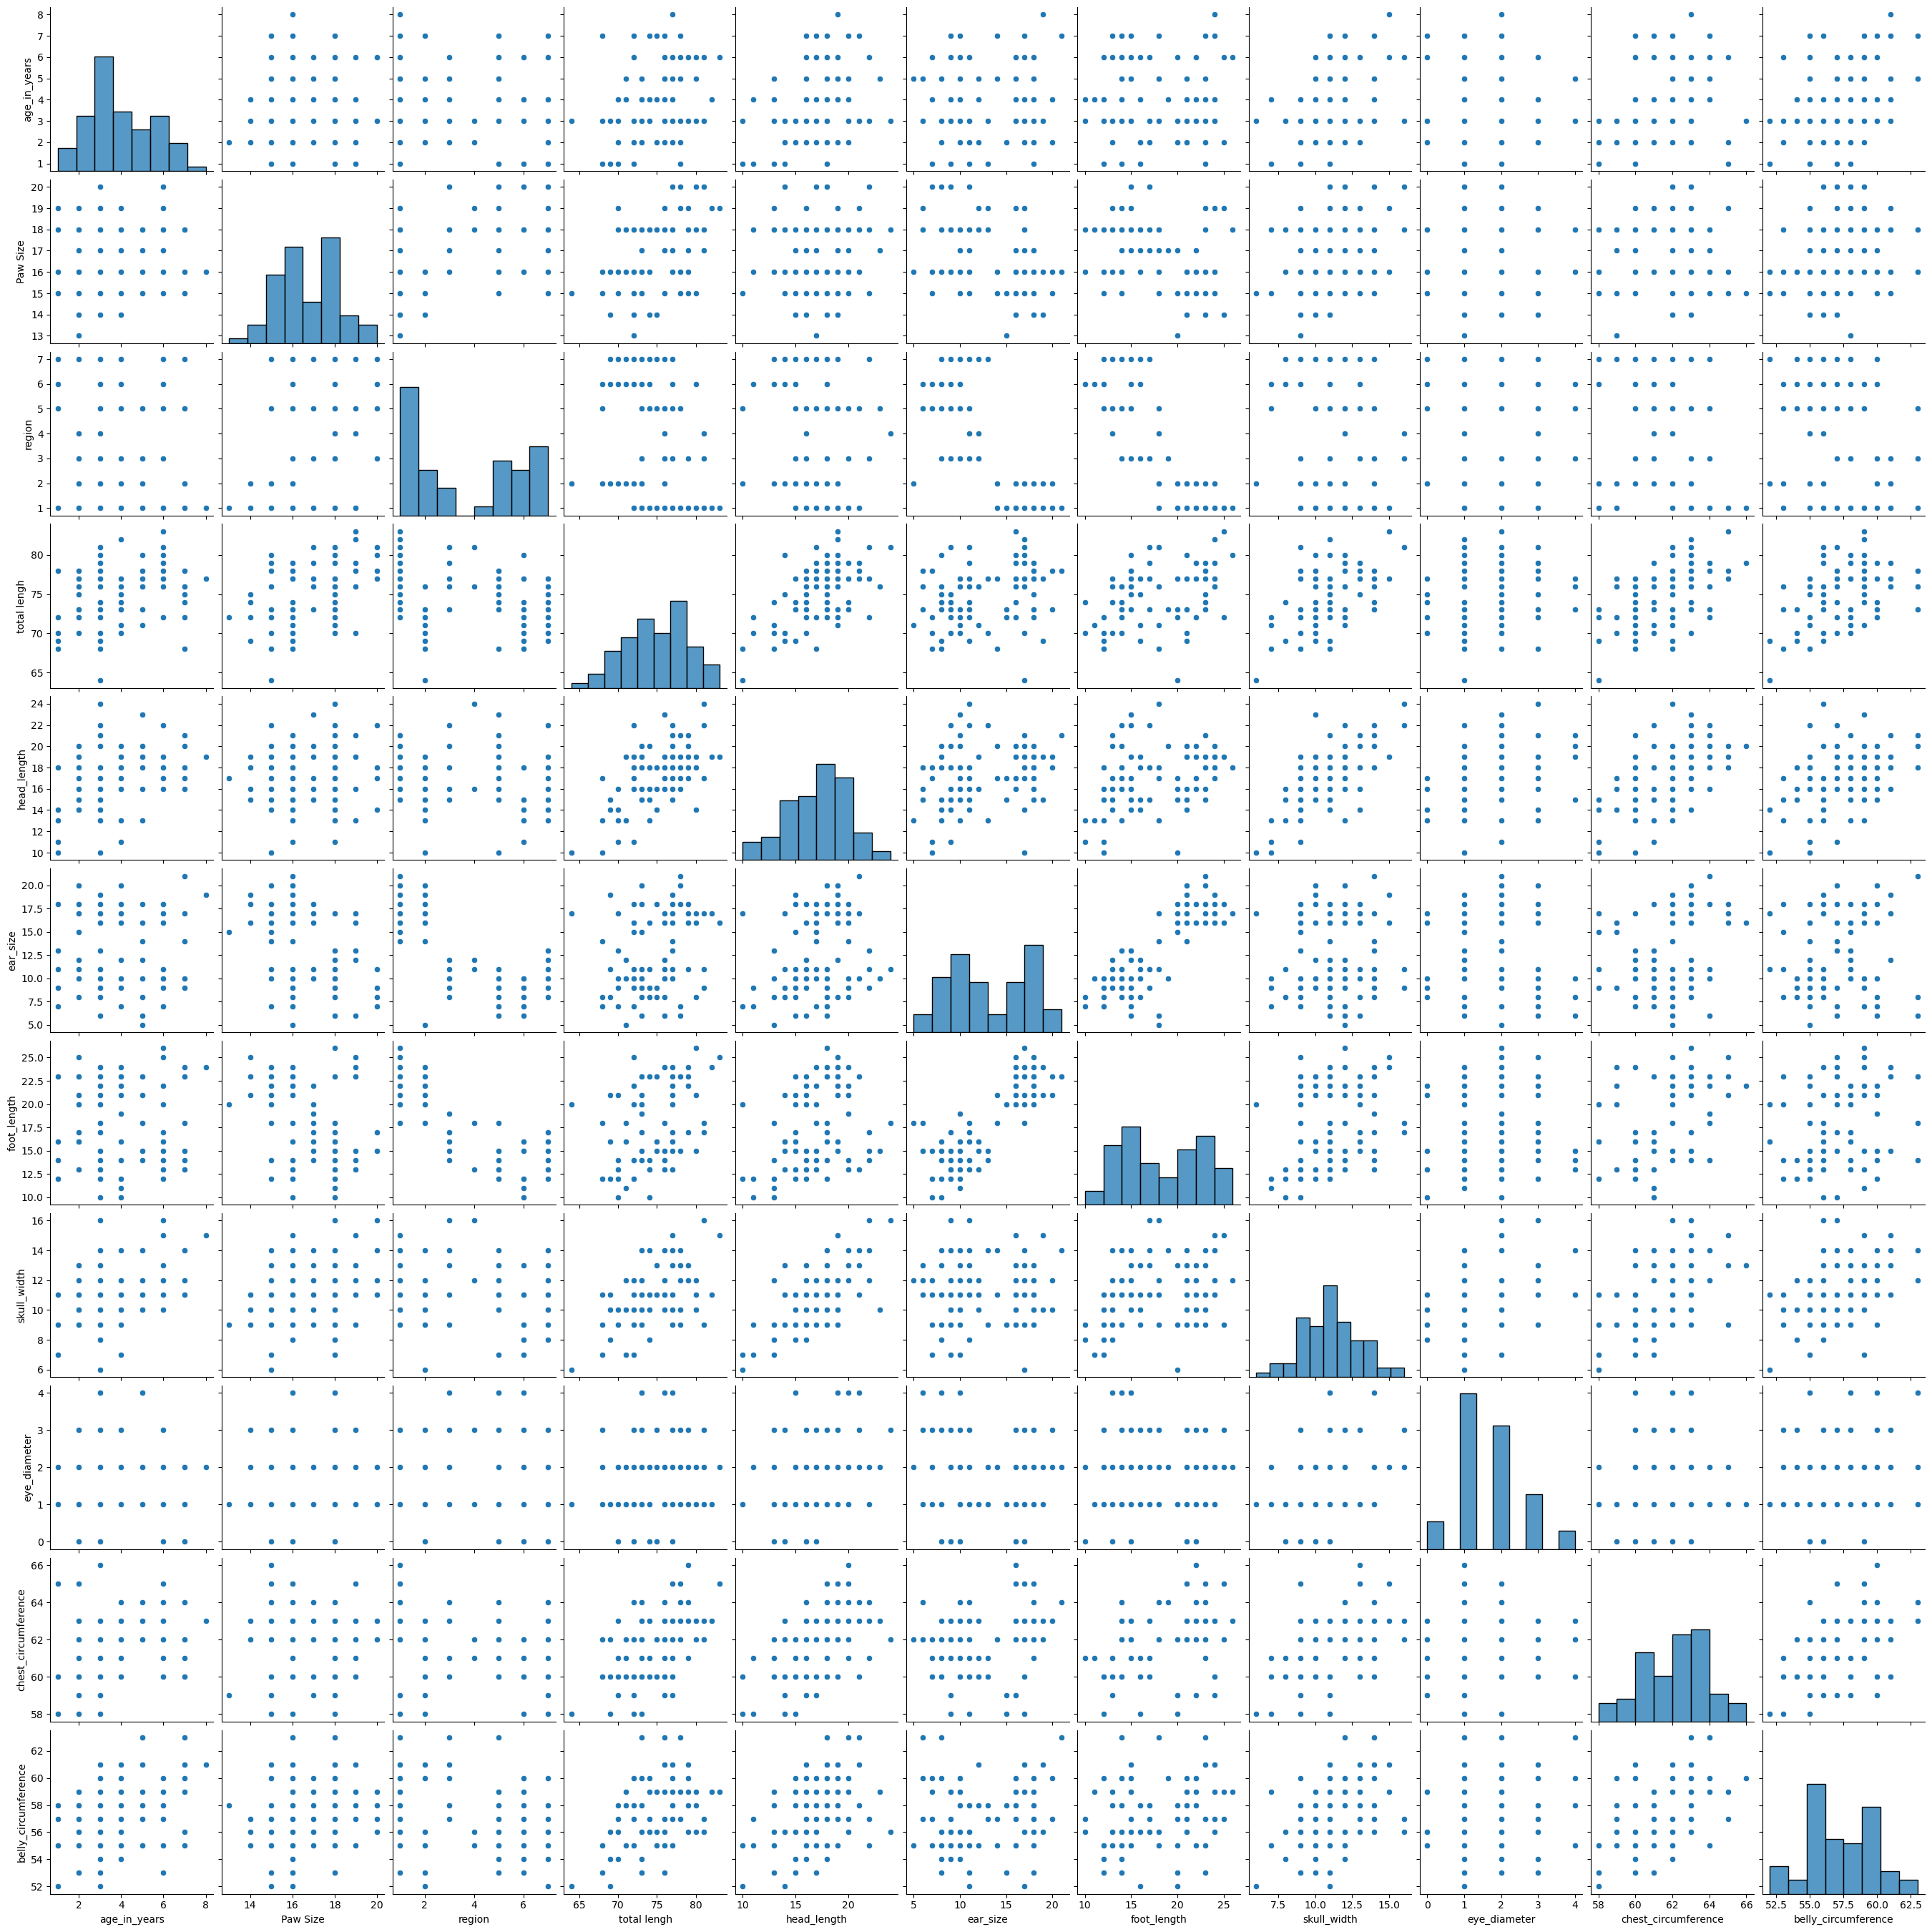

In [64]:
# Creating a pairplot for numerical columns
plt.figure(figsize=(12, 8))
sns.pairplot(koala_data_encoded[numerical_columns])

# Show the pairplot
plt.show()

Head Length and Total Length: The scatter plot between head length and total length confirms the positive relationship suggested by the heatmap. Koalas with longer heads tend to have longer total body lengths, and this pattern is consistent across different individuals.

Distribution Patterns: The diagonal histograms in the pairplot show the distributions of each variable. For instance, the age_in_years column might show a skewed distribution (e.g., younger koalas being more frequent in the dataset), which provides insights into the age structure of the population.

Foot Length and Paw Size: There is also a visible positive trend between foot length and paw size, indicating that koalas with larger feet tend to have larger paws. This relationship is biologically intuitive, as koalas with larger extremities are likely to be larger overall.

By using the pairplot, we can visually confirm correlations and observe how variables like age, head length, and foot size interact with each other across the entire dataset.

# Section 2 - Visualisation

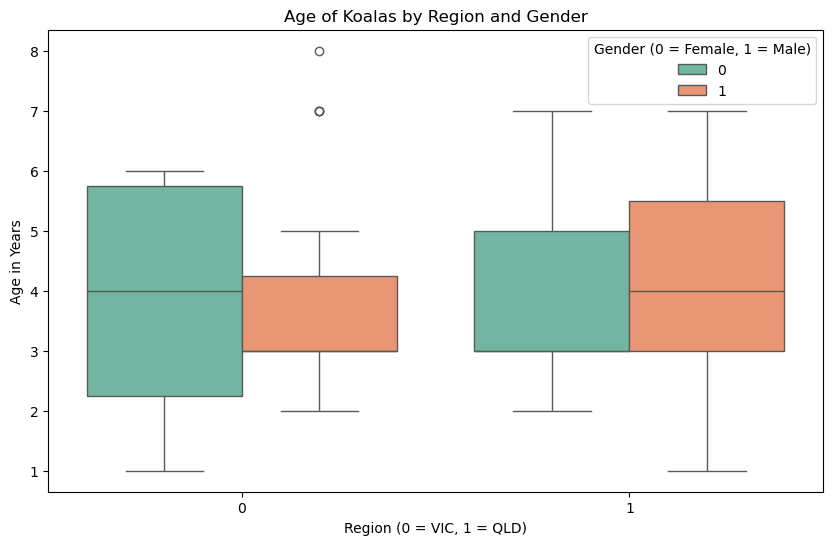

In [154]:
# Creating a boxplot to show koala age by region and gender
plt.figure(figsize=(10, 6))

# Using seaborn's boxplot function to visualize age distribution
sns.boxplot(x='habitat_QLD', y='age_in_years', hue='gender_m', data=koala_data_encoded, palette='Set2')

# Adding labels and title
plt.title('Age of Koalas by Region and Gender')
plt.xlabel('Region (0 = VIC, 1 = QLD)')
plt.ylabel('Age in Years')
plt.legend(title='Gender (0 = Female, 1 = Male)')
plt.show()

##### Comparing average ages across regions: The box plot helps us see if there’s a significant difference in the average age of koalas between Queensland and Victoria. For instance, if koalas in Queensland tend to live longer on average, this might suggest that conservation efforts or environmental conditions in that region are more favorable.
##### Gender comparison: By including gender in the analysis, the bar plot highlights whether male or female koalas tend to live longer on average. This could provide insights into gender-based survival patterns, which could be useful for shaping conservation strategies.
##### Simplified insights: The box plot offers a more direct way to compare groups when your focus is on averages rather than the full distribution of ages.

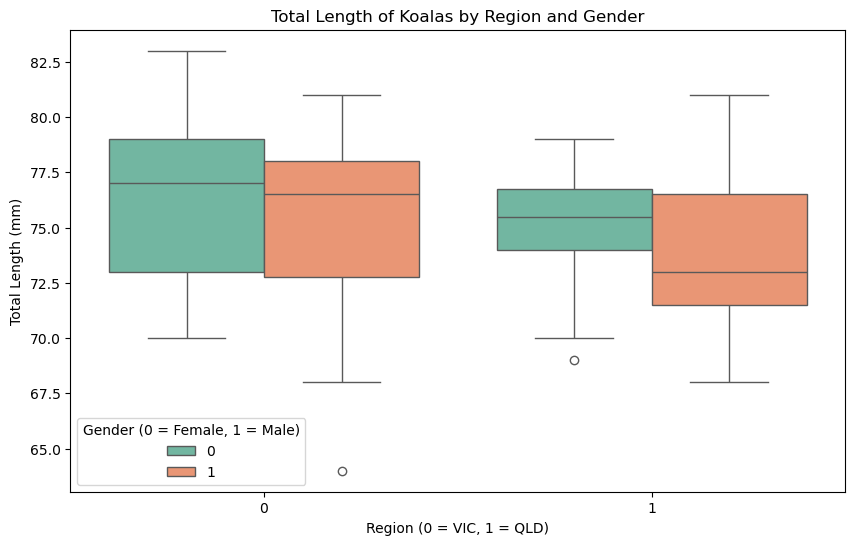

In [150]:
# Creating a boxplot to show total length by region and gender
plt.figure(figsize=(10, 6))

# Using seaborn's boxplot function
sns.boxplot(x='habitat_QLD', y='total lengh', hue='gender_m', data=koala_data_encoded, palette='Set2')

# Adding labels and title
plt.title('Total Length of Koalas by Region and Gender')
plt.xlabel('Region (0 = VIC, 1 = QLD)')
plt.ylabel('Total Length (mm)')
plt.legend(title='Gender (0 = Female, 1 = Male)')
plt.show()

##### The boxplot allows us to compare the total length of koalas between different regions, such as Queensland and Victoria. This comparison helps to observe if koalas in one region tend to be larger or smaller than those in the other region. For instance:

##### If koalas in Queensland have longer bodies on average, it could suggest that the environmental conditions in Queensland are more conducive to physical growth, or it might be linked to regional dietary differences.
##### The variability in total length might also differ between regions, indicating a more homogeneous population in one region (with less variation in size) compared to another region with more diversity in koala body lengths.

# Section 3 - Analysis

#### 1. Is the mean head length of the Koalas significantly different from 92.0 mm?

##### To determine if the mean head length of the koalas is significantly different from 92.0 mm, you can perform a one-sample t-test. This statistical test compares the mean of a sample (koalas' head length) to a known value (92.0 mm) to determine if there is a significant difference.

##### Steps for the Analysis:
##### Null Hypothesis (H₀): The mean head length of koalas is equal to 92.0 mm.
##### Alternative Hypothesis (H₁): The mean head length of koalas is significantly different from 92.0 mm.

In [98]:
# Extracting the head_length column
head_lengths = koala_data_encoded['head_length']

# Perform a one-sample t-test
t_stat, p_value = stats.ttest_1samp(head_lengths, 92.0)

# Displaying the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpreting the p-value
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. The mean head length is significantly different from 92.0 mm.")
else:
    print("Fail to reject the null hypothesis. The mean head length is not significantly different from 92.0 mm.")

T-statistic: -239.2778641283333
P-value: 2.064855139173485e-118
Reject the null hypothesis. The mean head length is significantly different from 92.0 mm.


#### 2. Do male and female Koalas have significantly different mean head lengths?

##### To determine whether male and female koalas have significantly different mean head lengths, you can perform an independent two-sample t-test. This test compares the means of two independent groups (male and female koalas) to see if there is a statistically significant difference between their head lengths.

##### Null Hypothesis (H₀): The mean head length of male koalas is equal to the mean head length of female koalas.
##### Alternative Hypothesis (H₁): The mean head length of male koalas is significantly different from the mean head length of female koalas.

In [106]:
# Extracting the head lengths of male and female koalas
male_head_lengths = koala_data_encoded[koala_data_encoded['gender_m'] == 1]['head_length']
female_head_lengths = koala_data_encoded[koala_data_encoded['gender_f'] == 1]['head_length']

# Perform an independent two-sample t-test
t_stat, p_value = stats.ttest_ind(male_head_lengths, female_head_lengths, equal_var=False)

# Displaying the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpreting the p-value
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. Male and female koalas have significantly different mean head lengths.")
else:
    print("Fail to reject the null hypothesis. Male and female koalas do not have significantly different mean head lengths.")

T-statistic: 1.120513018368049
P-value: 0.26584650682638766
Fail to reject the null hypothesis. Male and female koalas do not have significantly different mean head lengths.


#### 3. Can we predict the total length of a Koala based on its head length?

##### To determine whether we can predict the total length of a koala based on its head length, we can perform a simple linear regression. This statistical method models the relationship between two variables (in this case, total length and head length) and allows us to predict the value of one variable based on the other.

##### Model: We will fit a simple linear regression model where:

##### The independent variable (X) is head length.
##### The dependent variable (Y) is total length.
##### Hypothesis:

##### Null Hypothesis (H₀): There is no relationship between head length and total length.
##### Alternative Hypothesis (H₁): There is a significant relationship between head length and total length, and head length can be used to predict total length.


                            OLS Regression Results                            
Dep. Variable:            total lengh   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     45.13
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           2.35e-09
Time:                        21:24:32   Log-Likelihood:                -209.15
No. Observations:                  83   AIC:                             422.3
Df Residuals:                      81   BIC:                             427.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          61.3881      2.036     30.154      

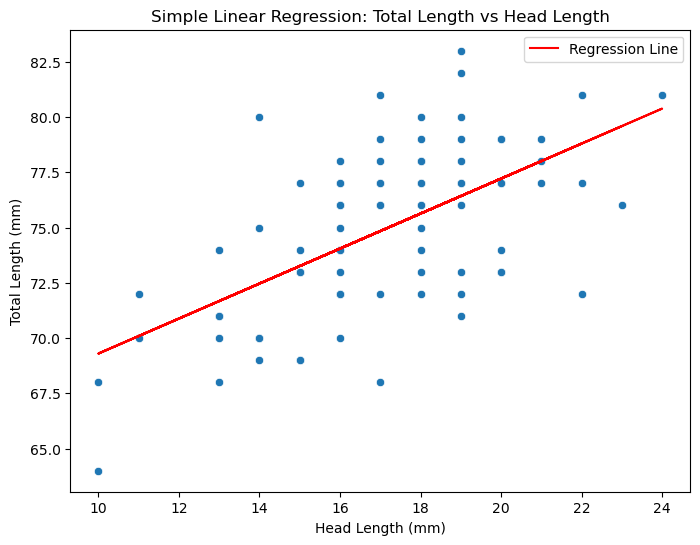

In [113]:
# Defining the independent (head length) and dependent (total length) variables
X = koala_data_encoded['head_length']
Y = koala_data_encoded['total lengh']

# Adding a constant to the independent variable (required for statsmodels)
X = sm.add_constant(X)

# Fitting the linear regression model
model = sm.OLS(Y, X).fit()

# Displaying the model summary
print(model.summary())

# Plotting the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x='head_length', y='total lengh', data=koala_data_encoded)
plt.plot(koala_data_encoded['head_length'], model.predict(X), color='red', label='Regression Line')
plt.title('Simple Linear Regression: Total Length vs Head Length')
plt.xlabel('Head Length (mm)')
plt.ylabel('Total Length (mm)')
plt.legend()
plt.show()

##### Explanation:
##### Model Summary: This will give you important metrics like the R-squared value, which indicates how well the model explains the variability of total length based on head length. It also provides the p-value for the regression coefficient, helping to determine if the relationship is statistically significant.
##### Regression Line: The scatter plot with the red regression line shows how well head length predicts total length.

##### R-squared: This value represents the proportion of variance in the dependent variable (total length) explained by the independent variable (head length). A higher R-squared value (close to 1) means a better fit.
##### P-value: If the p-value for the head length coefficient is less than 0.05, we can conclude that head length is a significant predictor of total length.
##### Interpretation:
##### If the p-value for the head length coefficient is less than 0.05, we can reject the null hypothesis and conclude that head length is a significant predictor of total length.
##### The R-squared value will help you understand how much of the variation in total length is explained by the variation in head length. The higher the R-squared, the better the prediction.

#### 4. Can we predict the total length of a Koala based on multiple factors such as head length, skull width, and foot length?

##### To determine whether we can predict the total length of a koala based on multiple factors such as head length, skull width, and foot length, we can perform a multiple linear regression. This technique extends simple linear regression by using multiple independent variables to predict a dependent variable.

##### Model: We will fit a multiple linear regression model where:

##### The dependent variable (Y) is total length.
##### The independent variables (X) are head length, skull width, and foot length.
##### Hypothesis:

##### Null Hypothesis (H₀): None of the independent variables (head length, skull width, foot length) can predict the total length.
##### Alternative Hypothesis (H₁): At least one of the independent variables can significantly predict the total length.

In [125]:
# Defining the independent variables (head length, skull width, foot length)
X = koala_data_encoded[['head_length', 'skull_width', 'foot_length']]

# Defining the dependent variable (total length)
Y = koala_data_encoded['total lengh']

# Adding a constant to the independent variables (required for statsmodels)
X = sm.add_constant(X)

# Fitting the multiple linear regression model
model = sm.OLS(Y, X).fit()

# Displaying the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            total lengh   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     20.06
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           9.24e-10
Time:                        22:16:32   Log-Likelihood:                -204.04
No. Observations:                  83   AIC:                             416.1
Df Residuals:                      79   BIC:                             425.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          58.6066      2.126     27.569      

##### Explanation:
##### Independent Variables: The independent variables are head length, skull width, and foot length.
##### Dependent Variable: The dependent variable is total length.
##### Model Summary: The summary displays key metrics such as the R-squared value, p-values for each predictor, and coefficients for the regression equation.
##### Key Metrics:
##### R-squared: This value indicates the proportion of the variance in the dependent variable (total length) that is explained by the independent variables. A higher R-squared value indicates a better fit.
##### P-values: Each independent variable will have a p-value that indicates whether that variable significantly contributes to predicting total length. A p-value less than 0.05 suggests that the variable is a significant predictor.
##### Coefficients: These represent the impact of each independent variable on the dependent variable. For example, a positive coefficient for head length means that as head length increases, total length increases, holding other factors constant.
##### Interpretation:
##### If the R-squared value is high, it indicates that the model explains a large proportion of the variation in total length based on head length, skull width, and foot length.
##### If the p-value for any of the variables is less than 0.05, we can conclude that the variable significantly contributes to predicting total length.
##### The coefficients help interpret how much total length changes for a one-unit change in each predictor, holding the other predictors constant.

#### 5. Do environmental factors such as state affect Koala’s physical characteristics?

##### Linear Regression with Categorical Variables (Dummy Variables)
##### You can incorporate environmental factors like state as dummy variables in a multiple linear regression model. This approach treats state as an independent variable and physical characteristics (like head length, foot length, etc.) as the dependent variable.



In [130]:
import statsmodels.api as sm

# Defining the independent variables (including state as dummy variables)
X = koala_data_encoded[['habitat_QLD', 'habitat_VIC', 'head_length', 'skull_width', 'foot_length']]

# Defining the dependent variable (total length)
Y = koala_data_encoded['total lengh']

# Adding a constant to the independent variables (required for statsmodels)
X = sm.add_constant(X)

# Fitting the multiple linear regression model
model = sm.OLS(Y, X).fit()

# Displaying the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            total lengh   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     15.32
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           2.76e-09
Time:                        22:23:29   Log-Likelihood:                -203.48
No. Observations:                  83   AIC:                             417.0
Df Residuals:                      78   BIC:                             429.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          37.6347      1.990     18.912      

##### Explanation:
##### This model will explain whether the state (represented by habitat_QLD and habitat_VIC) significantly influences the physical characteristic being predicted (in this case, total length).
##### The coefficients for the state dummy variables will indicate the effect of each state on the physical characteristic. For example, if the coefficient for habitat_QLD is positive, koalas in Queensland might have longer bodies compared to other states.
##### Advantages:
##### This method lets you control for other variables (such as head length, foot length) while analyzing the effect of state.
##### It provides p-values for the state dummy variables to check their significance.


#### 6. What factors are correlated with the total length of a Koala?

##### To determine which factors are correlated with the total length of a koala, we can use a correlation matrix to identify the relationships between the numerical variables in your dataset and the total length. By examining the correlation coefficients, we can see which physical attributes have the strongest linear relationships with total length.

##### Steps:
##### Calculate the Correlation Matrix: This will show the correlation between total length and all other numerical variables.
##### Interpret the Correlation Coefficients:
##### A positive correlation means that as one variable increases, the other tends to increase.
##### A negative correlation means that as one variable increases, the other tends to decrease.
##### Values close to 1 or -1 indicate strong correlations, while values close to 0 suggest weak or no correlation.

Correlations with Total Length:
total lengh            1.000000
head_length            0.598185
skull_width            0.551348
chest_circumference    0.489757
Paw Size               0.419854
foot_length            0.386373
belly_circumference    0.371954
age_in_years           0.250753
ear_size               0.241791
habitat_VIC            0.190610
gender_f               0.183581
eye_diameter           0.171942
gender_m              -0.183581
habitat_QLD           -0.190610
region                -0.351411
koala_id              -0.411462
Name: total lengh, dtype: float64


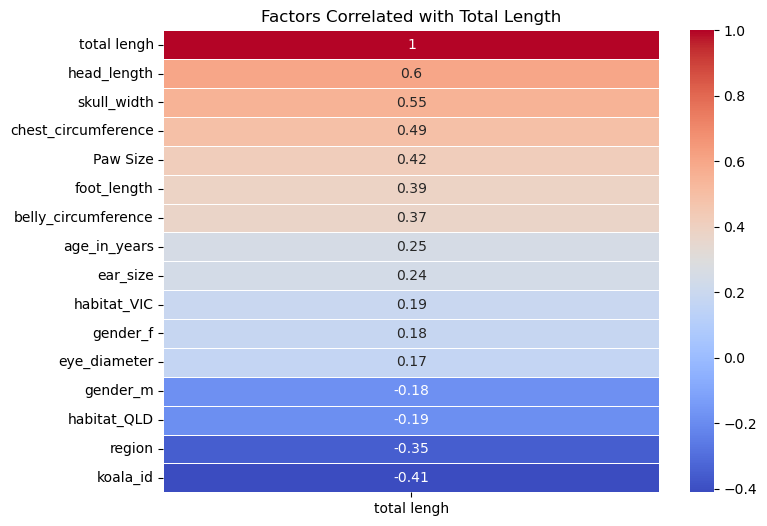

In [136]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = koala_data_encoded.corr()

# Extracting correlations with 'total lengh'
correlations_with_total_length = correlation_matrix['total lengh'].sort_values(ascending=False)

# Displaying the correlations
print("Correlations with Total Length:")
print(correlations_with_total_length)

# Plotting a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(correlations_with_total_length.to_frame(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Factors Correlated with Total Length')
plt.show()


##### Explanation:
##### corr(): This calculates the pairwise Pearson correlation between all numerical columns.
##### sort_values(): We use this to sort the correlations in descending order, so you can easily see the strongest correlations with total length.
##### Heatmap: The heatmap provides a visual representation of the strength of the correlation.
##### Interpretation:
##### Strong Positive Correlations: Variables with a correlation coefficient close to 1 have a strong positive relationship with total length. For example, if head length has a coefficient of 0.8, it means larger head lengths are associated with longer total lengths.
##### Negative Correlations: Variables with a negative coefficient suggest that as the value of one variable increases, total length tends to decrease. However, such negative correlations are typically rare for physical characteristics.
##### Weak or No Correlation: If a variable has a correlation coefficient close to 0, it indicates that the variable does not have a linear relationship with total length.
##### Conclusion:
##### This method explains clear picture of which physical factors (such as head length, foot length, paw size, etc.) are most correlated with the total length of a koala. The factors with the highest positive correlations are likely the ones most predictive of total length.

# Section 4 - Recommendations

#### The findings from this analysis offer valuable insights that can help shape conservation strategies for protecting koalas. We’ve identified strong connections between koala size and key physical traits like head length, foot size, and total body length, which are crucial indicators of a koala’s overall health and development. Moreover, the data suggests that environmental factors, such as the state or region where koalas live, can significantly influence these physical characteristics. For example, differences in total length and age between koalas in Queensland and Victoria highlight the need for conservation efforts tailored to the specific conditions of each region. Ensuring that koalas in diverse habitats receive the protection they need is essential for maintaining the species' genetic diversity and adaptability. By preserving these unique habitats and focusing on the distinct traits of koalas in different environments, we can better protect them against threats like habitat destruction and climate change. Ultimately, protecting koalas means protecting the ecosystems they depend on, ensuring the long-term survival and health of this iconic species.